In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import glob
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np

# Define Drive source and Local destination
drive_base_path = '/content/drive/MyDrive/Universal_Dataset'
local_base_path = '/content/MyDrive/'
categories = ['BACTERIAL PNEUMONIA', 'NORMAL', 'VIRAL PNEUMONIA']

# 1. Copy data from Drive to Local Storage
os.makedirs(local_base_path, exist_ok=True)

for category in categories:
    src_dir = os.path.join(drive_base_path, category)
    dest_dir = os.path.join(local_base_path, category)

    # Only copy if it hasn't been copied already in this session
    if not os.path.exists(dest_dir):
        print(f"Copying '{category}' to local storage... this might take a minute.")
        shutil.copytree(src_dir, dest_dir)
        print(f"✓ '{category}' copied successfully.")
    else:
        print(f"✓ '{category}' already exists locally.")

# 2. Map the new local file paths into a DataFrame
data = {'filepath': [], 'label': []}

for category in categories:
    folder_path = os.path.join(local_base_path, category)
    # Grabbing common image formats from the LOCAL path
    images = glob.glob(os.path.join(folder_path, '*.[jp][pn]*'))

    for img in images:
        data['filepath'].append(img)
        data['label'].append(category)

df = pd.DataFrame(data)
print(f"\nTotal images loaded from local storage: {len(df)}")

Copying 'BACTERIAL PNEUMONIA' to local storage... this might take a minute.
✓ 'BACTERIAL PNEUMONIA' copied successfully.
Copying 'NORMAL' to local storage... this might take a minute.
✓ 'NORMAL' copied successfully.
Copying 'VIRAL PNEUMONIA' to local storage... this might take a minute.
✓ 'VIRAL PNEUMONIA' copied successfully.

Total images loaded from local storage: 11726


/tmp/ipykernel_143/2953839396.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette='mako', order=categories)


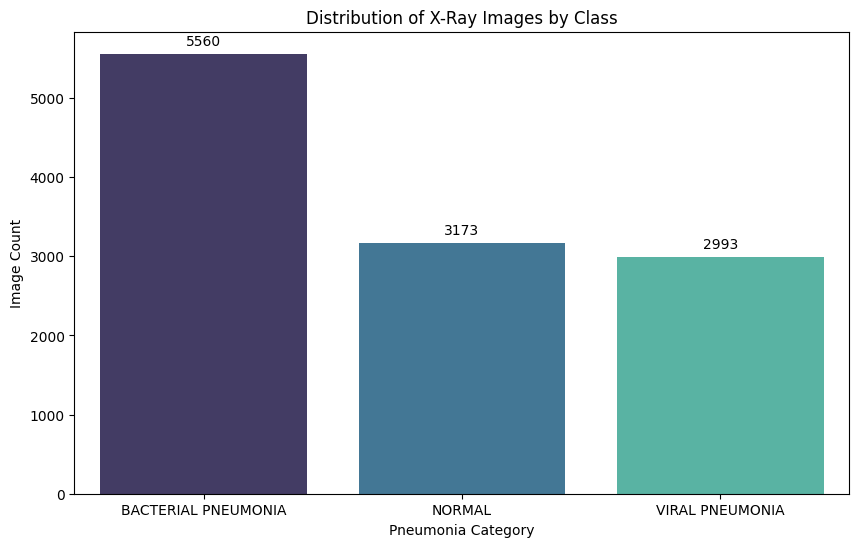

In [6]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='label', palette='mako', order=categories)
plt.title('Distribution of X-Ray Images by Class')
plt.xlabel('Pneumonia Category')
plt.ylabel('Image Count')

# Add exact counts above the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.show()

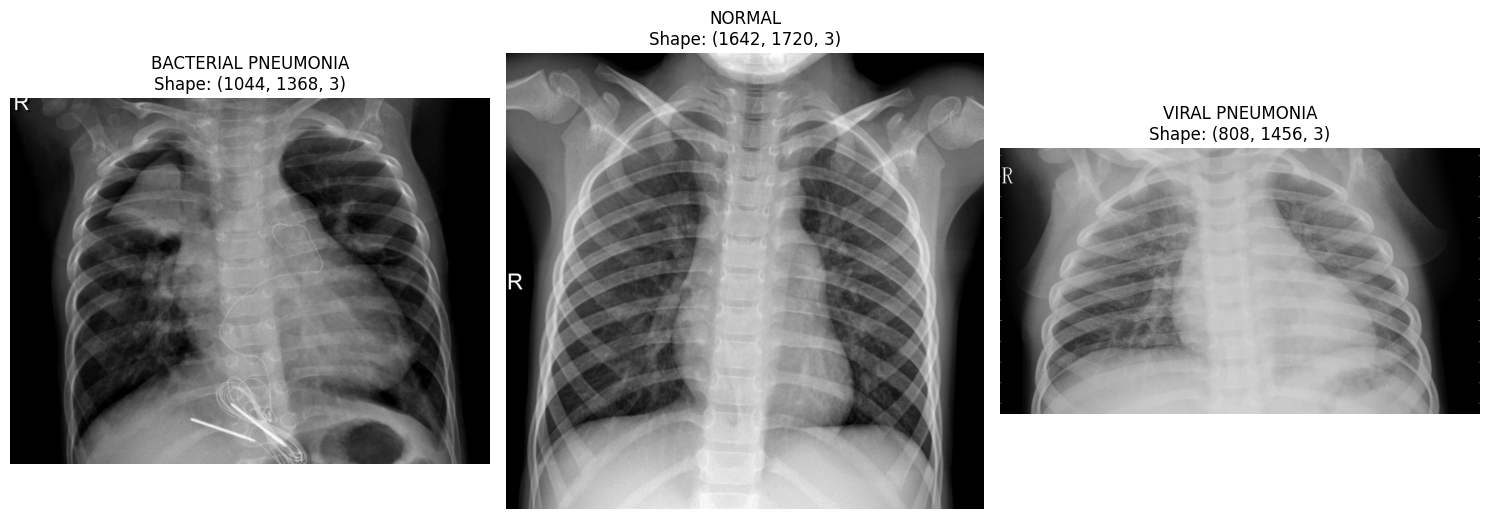

In [7]:
plt.figure(figsize=(15, 5))

for i, category in enumerate(categories):
    # Select a random image from the current category
    sample = df[df['label'] == category].sample(1).iloc[0]

    # Read image using OpenCV
    img = cv2.imread(sample['filepath'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB for matplotlib

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f"{category}\nShape: {img.shape}")
    plt.axis('off')

plt.tight_layout()
plt.show()

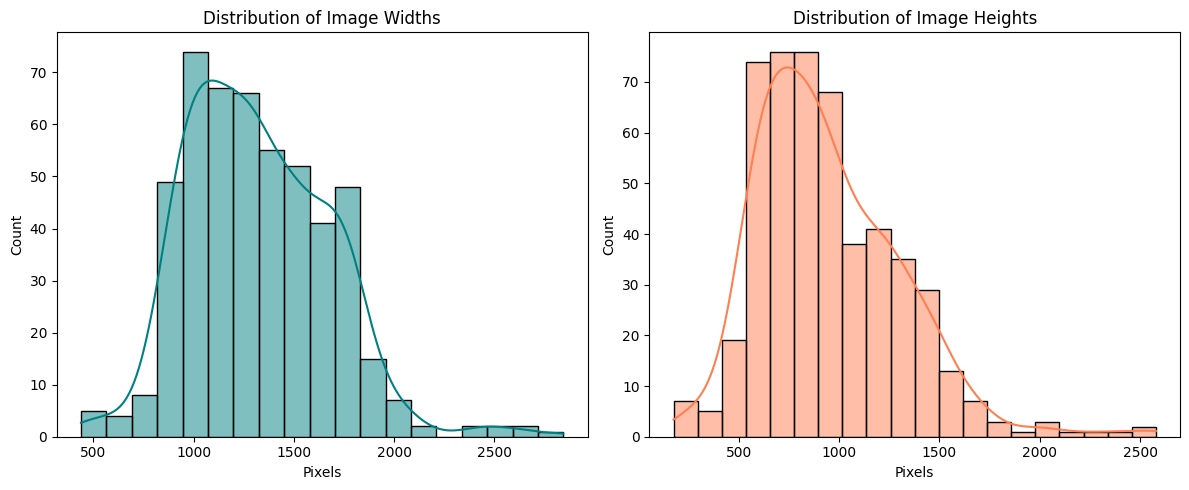

In [8]:
# Sample a subset to save time if the dataset is massive
sample_df = df.sample(min(500, len(df)))

widths, heights = [], []

for path in sample_df['filepath']:
    img = cv2.imread(path)
    if img is not None:
        heights.append(img.shape[0])
        widths.append(img.shape[1])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(widths, kde=True, color='teal')
plt.title('Distribution of Image Widths')
plt.xlabel('Pixels')

plt.subplot(1, 2, 2)
sns.histplot(heights, kde=True, color='coral')
plt.title('Distribution of Image Heights')
plt.xlabel('Pixels')

plt.tight_layout()
plt.show()